# PM N-body Simulation with BullFrog

LPT accurately describes structure formation at early times and on large scales,
but breaks down when particles start to cross (shell-crossing). The **Particle Mesh
(PM) method integrates the full equations of motion: forces are computed on a mesh
via an FFT-based Poisson solver, and particles are moved with a symplectic integrator.

---

## The BullFrog Integrator

**BullFrog** ([arXiv:2409.19049](https://arxiv.org/abs/2409.19049)) is a second-order
accurate **Drift–Kick–Drift (DKD)** integrator that operates in *D-time*
(growth-factor time $D_1$) instead of scale-factor time.


## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import numpy as np

/lustre/fswork/projects/rech/tkc/commun/venv/pm/lib/python3.11/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(


E0609 17:41:36.274702  241324 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0609 17:41:36.275291  241323 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0609 17:41:36.275366  241322 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Simulation Parameters


In [2]:
resolution = 256
mesh_size = (resolution,) * 3
box_size = (300.0, 300.0, 300.0)  # Mpc/h

t0 = 0.001  # start of PM integration
t1 = 1.0  # today
n_steps = 20

cosmo = jc.Planck18()
key = jax.random.PRNGKey(0)

## Initial Conditions

We draw a Gaussian random field with the Planck18 linear matter power spectrum.
This is the seed for all subsequent evolution.

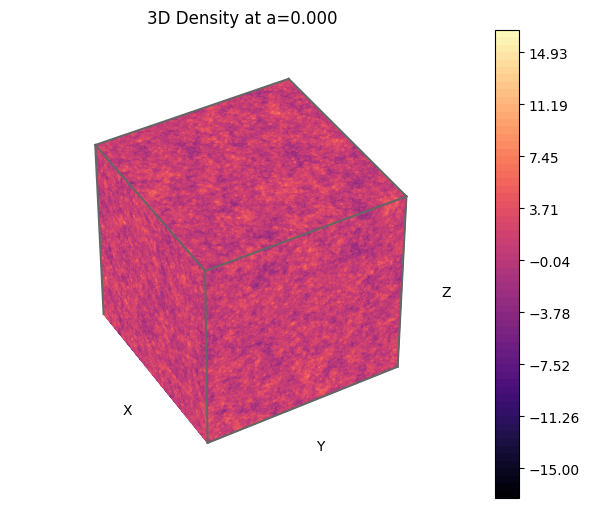

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
)

# Visualise a 2-D slice of the initial density contrast
initial_field.show()

## LPT Initialization

PM integration needs both **positions** and **momenta** at the start time $a_0$.  
We use first-order Lagrangian Perturbation Theory (1LPT / Zel'dovich) to generate them.

Calling `lpt` with a **scalar** `ts=t0` returns particle displacements `dx` and
conformal momenta `p` — *not* a painted density field.

In [4]:
dx, p = jfli.lpt(
    cosmo,
    initial_field,
    ts=t0,
    order=1,
    painting=jfli.PaintingOptions(target="particles"),
)

print(f"Displacement field  — shape: {dx.array.shape}, status: {dx.status}")
print(f"Momentum field      — shape: {p.array.shape},  status: {p.status}")

Displacement field  — shape: (256, 256, 256, 3), status: FieldStatus.LPT1
Momentum field      — shape: (256, 256, 256, 3),  status: FieldStatus.LPT1


## Building the BullFrog Solver

The solver is an `equinox.Module` that bundles the integration scheme with its
hyperparameters. Key fields:

| Field | Type | Description |
|-------|------|-------------|
| `interp_kernel` | `AbstractInterp` | Controls what is saved at each snapshot (here: painted density) |
| `time_stepping` | `str` | Internal time variable: `"a"`, `"D"` (growth factor), or `"log_a"` |
| `n_steps` | `int` | Total number of PM steps from $a_0$ to $a_1$ |

### `time_stepping` options

| Value | Spacing | When to use |
|-------|---------|-------------|
| `"a"` | Uniform in scale factor | Simple but over-resolves late times |
| `"D"` | Uniform in $D_1$ (growth factor) | **Default — recommended.** Even coverage of structure formation |
| `"log_a"` | Logarithmic in $a$ | Useful for very early-time studies |

### Velocity conversion

`BullFrog.init()` is called automatically by `nbody()`. It converts the LPT conformal
momentum $\mathbf{p}$ (returned by `lpt`) to the D-time velocity:

$$\boldsymbol{\pi} = \frac{\mathbf{p}}{G_f(a_0)}$$

You do **not** need to perform this conversion manually — just pass `p` directly.

### Mass-assignment order & deconvolution

Particles are assigned to the grid with a B-spline window of a chosen **order** &mdash; `"ngp"` (1), `"cic"` (2), `"tsc"` (3) or `"pcs"` (4); higher orders are smoother and suppress aliasing at the cost of more compute. This appears in **two independent places**:

| Where | Role | Controls |
|-------|------|----------|
| `PaintingOptions(order=, deconvolution=)` | projection | the **saved** density you analyse (`target="density"`) |
| `BullFrog(order=, deconvolution=)` | solver | the **force** assignment inside the Poisson solve |

`deconvolution=True` divides the painted field by its assignment window in Fourier space. On the **projection** it removes the window from the density you measure &mdash; but it *sharpens* the field (it can go negative, so it is for $P(k)$/Fourier use, not a density to visualise). On the **solver** it deconvolves the window before the force read-out. Both default to `False`.

In [5]:
solver = jfli.BullFrog(
    # The painting (projection) sets the SAVED density: its mass-assignment `order`
    # (ngp/cic/tsc/pcs) and an optional Fourier-space window `deconvolution`.
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="density", order="cic", deconvolution=False)),
    time_stepping="D",  # uniform in growth-factor time (recommended)
    n_steps=n_steps,
    t0=t0,
    t1=t1,
    # The solver carries its OWN order/deconvolution for the FORCE mass assignment in the
    # Poisson solve (separate from the projection above; the two are never shared).
    order="cic",
    deconvolution=False,
)

## Running the Simulation

We request snapshots at three scale factors: $a = 0.5$ (z=1), $a = 0.7$ (z≈0.43),
and $a = 1.0$ (z=0, today).  
The integrator sub-steps uniformly between $a_0$ and each snapshot.

In [6]:
ts = jnp.array([0.5, 0.7, 1.0])  # snapshot scale factors

density_result = jfli.nbody(
    cosmo,
    dx,
    p,
    ts=ts,
    solver=solver,
)

print(f"Output type   : {type(density_result).__name__}")
print(f"Output shape  : {density_result.shape}")
print(f"Scale factors : {density_result.scale_factors}")
print(f"Redshifts     : {jc.utils.a2z(density_result.scale_factors).round(2)}")

Output type   : DensityField
Output shape  : (3, 256, 256, 256)
Scale factors : [1.  0.7 0.5]


Redshifts     : [0.         0.42999998 1.        ]


## Visualising Structure Growth

We project the 3-D density field along the z-axis ($\log(1+\delta)$ stretch)
to reveal voids, filaments and halos at each epoch.

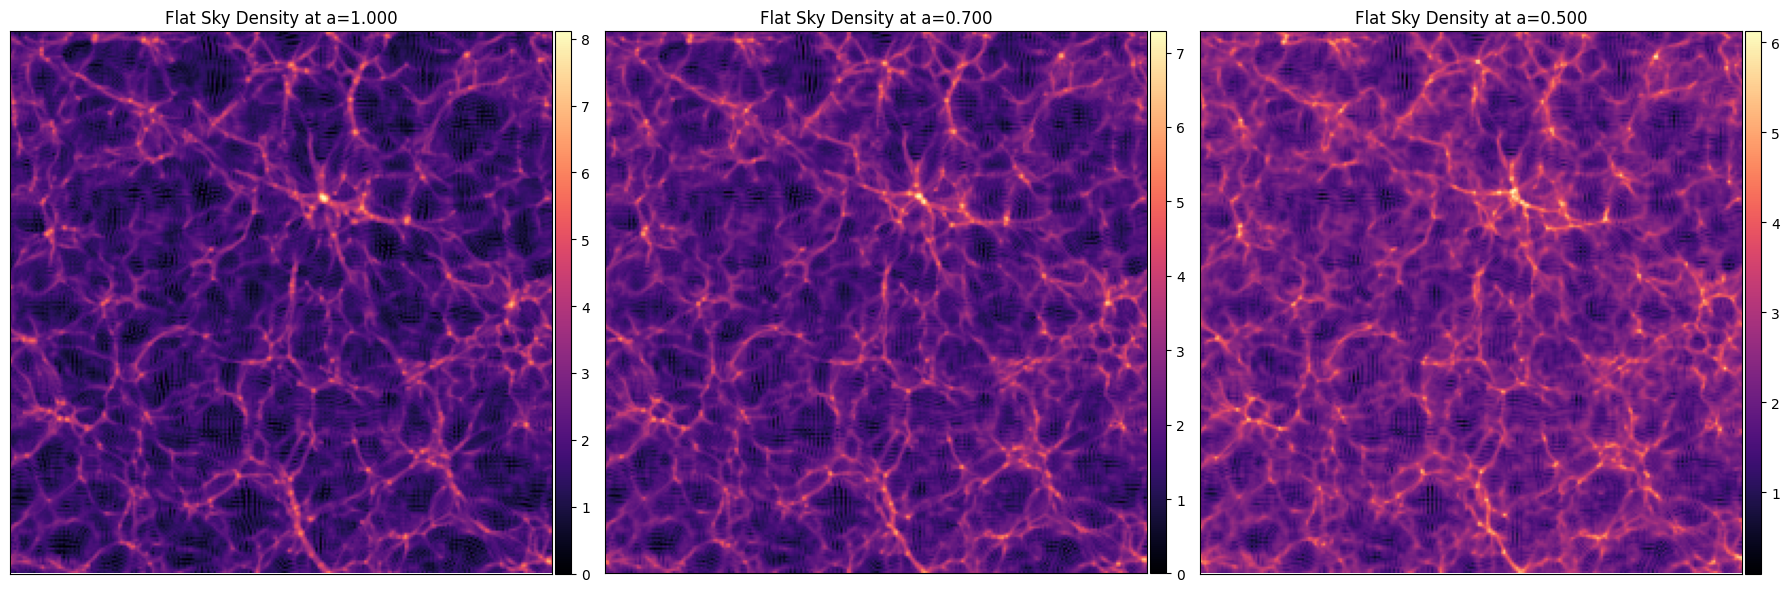

In [7]:
density_result.project().apply_fn(jnp.log1p).show()

## Validating Against Theory: 3-D Matter Power Spectrum

The standard validation for a PM simulation is the **3-D matter power spectrum** $P(k)$,
compared against the nonlinear **Halofit** prediction.

A particle-sampled density carries two sampling artefacts — exactly the same pair we removed
on the sphere in [notebook 2](02-LPT-Simulation.ipynb):

- the **CIC mass-assignment window** smooths the field and suppresses power toward the grid
  Nyquist frequency;
- **Poisson shot noise** adds a constant floor $1/\bar n$, with
  $\bar n = N_\mathrm{part}/V_\mathrm{box}$.

`DensityField.power` removes both in one call: `compensate_order="cic"` deconvolves the
assignment window and `shotnoise=("cic", nbar)` subtracts the aliased shot noise. What is left
is the PM **force resolution** itself — below $\sim 2$–$3$ grid cells PM cannot resolve the
force, and the spectrum droops there regardless of these corrections.

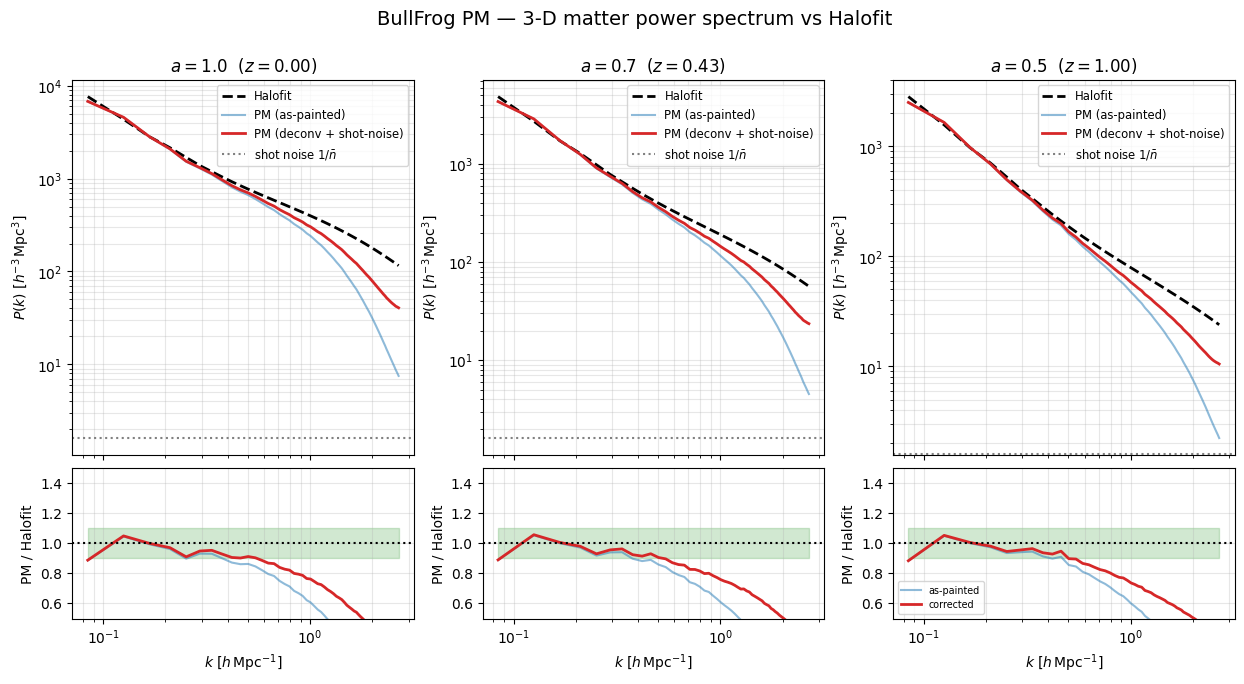

In [8]:
# Shot-noise density: one particle per cell -> nbar = N_part / V_box
nbar = float(np.prod(mesh_size) / np.prod(box_size))

pk_raw = density_result.power()  # as-painted
pk_corr = density_result.power(
    compensate_order="cic",  # deconvolve CIC + subtract shot noise
    shotnoise=("cic", nbar),
)

n_snaps = len(density_result.scale_factors)
k = np.asarray(pk_raw.wavenumber)
theory_pk = [
    np.asarray(
        jax.jit(jc.power.nonlinear_matter_power, static_argnames=["nonlinear_fn"])(
            cosmo, jnp.asarray(k), a=float(density_result.scale_factors[i]), nonlinear_fn=jc.power.halofit
        )
    )
    for i in range(n_snaps)
]

fig, axes = plt.subplots(
    2, n_snaps, figsize=(5 * n_snaps, 7), sharex="col", gridspec_kw={"height_ratios": [2.5, 1], "hspace": 0.05}
)
for i in range(n_snaps):
    a_snap = float(density_result.scale_factors[i])
    z_snap = float(jc.utils.a2z(a_snap))
    raw_i = np.asarray(pk_raw.array[i])
    corr_i = np.asarray(pk_corr.array[i])

    axes[0, i].loglog(k, theory_pk[i], "k--", lw=2, label="Halofit")
    axes[0, i].loglog(k, raw_i, color="C0", alpha=0.5, label="PM (as-painted)")
    axes[0, i].loglog(k, corr_i, color="C3", lw=2, label="PM (deconv + shot-noise)")
    axes[0, i].axhline(1.0 / nbar, color="grey", ls=":", label=r"shot noise $1/\bar n$")
    axes[0, i].set_title(f"$a={a_snap:.1f}$  ($z={z_snap:.2f}$)")
    axes[0, i].set_ylabel(r"$P(k)$ [$h^{-3}\,\mathrm{Mpc}^3$]")
    axes[0, i].legend(fontsize="small")
    axes[0, i].grid(True, which="both", alpha=0.3)

    axes[1, i].semilogx(k, raw_i / theory_pk[i], color="C0", alpha=0.5, label="as-painted")
    axes[1, i].semilogx(k, corr_i / theory_pk[i], color="C3", lw=2, label="corrected")
    axes[1, i].axhline(1.0, color="black", ls=":")
    axes[1, i].fill_between(k, 0.9, 1.1, alpha=0.18, color="green")
    axes[1, i].set_ylim(0.5, 1.5)
    axes[1, i].set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
    axes[1, i].set_ylabel("PM / Halofit")
    axes[1, i].grid(True, which="both", alpha=0.3)
    if i == n_snaps - 1:
        axes[1, i].legend(loc="lower left", fontsize="x-small")

fig.suptitle("BullFrog PM — 3-D matter power spectrum vs Halofit", fontsize=14)
plt.tight_layout()
plt.show()

## Deconvolving at paint time vs power time

The projection `deconvolution=True` flag removes the CIC window from the painted density in Fourier space &mdash; the **field-level** equivalent of the **spectrum-level** `power(compensate_order="cic")` used above. Below we paint the $a=1$ snapshot both ways and confirm they remove the window identically (the curves overlap, both lifted above the as-painted spectrum at high $k$).

In practice prefer the spectrum-level `power(compensate_order=, shotnoise=)`: paint-time deconvolution amplifies the Poisson floor by $1/W(k)^2$ and yields a sharpened field that can go negative, so it is not a clean density to visualise.

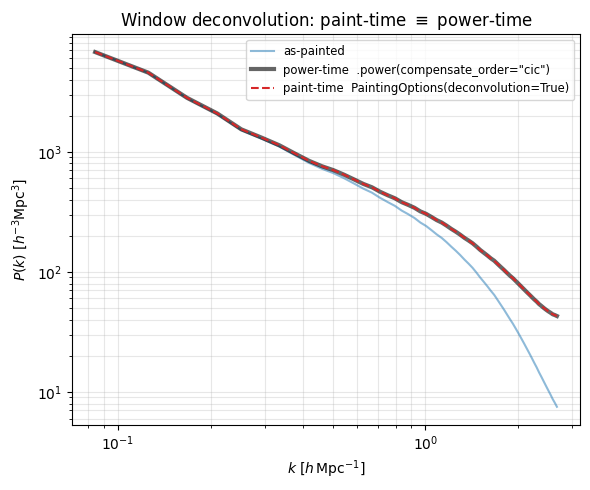

In [9]:
# Paint-time vs power-time deconvolution remove the CIC window IDENTICALLY. To compare them
# we must paint the SAME particles both ways, so we grab the a=1 particle snapshot first
# (a separate nbody with a different `ts` would land on a slightly different state).
solver_part = jfli.BullFrog(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="particles")),
    time_stepping="D",
    n_steps=n_steps,
    t0=t0,
    t1=t1,
)
particles_a1 = jfli.nbody(cosmo, dx, p, ts=jnp.array([1.0]), solver=solver_part)

d_aspainted = particles_a1.paint(order="cic", deconvolution=False)
d_paintdec = particles_a1.paint(order="cic", deconvolution=True)

pk_aspainted = np.asarray(d_aspainted.power().array)  # as-painted
pk_paintdec = np.asarray(d_paintdec.power().array)  # deconvolved at PAINT time
pk_powerdec = np.asarray(d_aspainted.power(compensate_order="cic").array)  # deconvolved at POWER time
kk = np.asarray(d_aspainted.power().wavenumber)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(kk, pk_aspainted, color="C0", alpha=0.5, label="as-painted")
ax.loglog(kk, pk_powerdec, color="k", lw=3, alpha=0.6, label=r'power-time  .power(compensate_order="cic")')
ax.loglog(kk, pk_paintdec, color="C3", lw=1.5, ls="--", label=r"paint-time  PaintingOptions(deconvolution=True)")
ax.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
ax.set_ylabel(r"$P(k)$ [$h^{-3}\mathrm{Mpc}^3$]")
ax.set_title("Window deconvolution: paint-time $\\equiv$ power-time")
ax.legend(fontsize="small")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Next Steps

This notebook showed the simplest BullFrog setup: fixed snapshots in a cubic box.  
`jax-fli` also supports:

- **Lightcone shells** (`nb_shells=N`): automatically space snapshots in comoving distance
  so the entire lightcone fits inside the box — see notebook 04.
- **Spherical and flat-sky painting** (`target="spherical"` / `target="flat"`):
  paint particles onto HEALPix maps or 2-D flat maps during integration.
- **Differentiable integration** (`adjoint="checkpointed"`): memory-efficient gradients
  through the full N-body run for field-level inference — see notebooks 10–11.